Eq(log(y(x)), C1 - asinh(x/y(x))/k)
Невязка (должна быть 0 после simplify с ограничениями): (C1 - asinh(x/y(x))/k)/(k*sqrt(x**2 + (C1 - asinh(x/y(x))/k)**2) - x) + (x*Derivative(y(x), x)/y(x)**2 - 1/y(x))/(k*sqrt(x**2/y(x)**2 + 1))


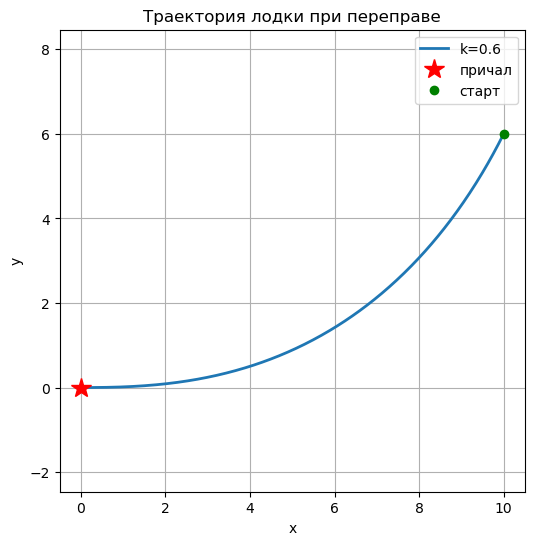

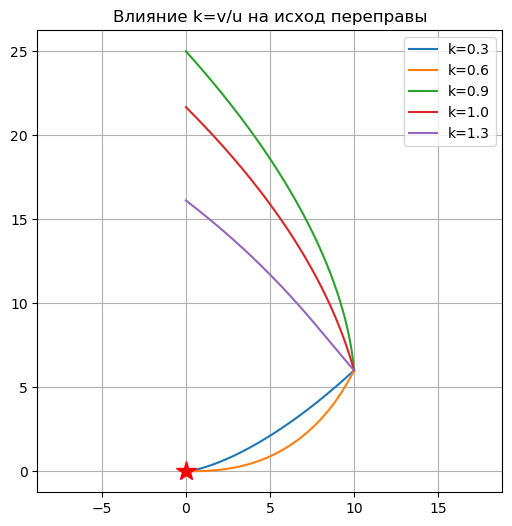

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

x, y, k = sp.symbols('x y k', positive=True)
u = sp.Function('u')
Y = sp.Function('y')

# Исходное ОДУ
r = sp.sqrt(x**2 + Y(x)**2)
ode = sp.Eq(Y(x).diff(x), -Y(x) / (k*r - x))

# Аналитическое решение через dsolve (hint для однородных уравнений)
sol = sp.dsolve(ode, Y(x), hint='1st_homogeneous_coeff_best')
sol_simpl = sp.simplify(sol)
print(sol_simpl)

# Проверка подстановкой
check = sp.simplify(ode.lhs.subs(Y(x), sol.rhs).doit() - ode.rhs.subs(Y(x), sol.rhs))
print("Невязка (должна быть 0 после simplify с ограничениями):", check)

# --- Численная проверка + фазовый портрет траекторий ---
def rhs(x, y, k_val=0.6):
    r = np.sqrt(x**2 + y**2)
    return -y / (k_val*r - x)

from scipy.integrate import solve_ivp

x0, y0 = 10.0, 6.0
k_val = 0.6

sol_num = solve_ivp(lambda x, y: rhs(x, y, k_val), [x0, 1e-3], [y0],
                     dense_output=True, rtol=1e-9, atol=1e-9)

xs = np.linspace(x0, sol_num.t[-1], 400)
ys = sol_num.sol(xs)[0]

plt.figure(figsize=(6,6))
plt.plot(xs, ys, lw=2, label=f'k={k_val}')
plt.plot(0, 0, 'r*', markersize=15, label='причал')
plt.plot(x0, y0, 'go', label='старт')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Траектория лодки при переправе')
plt.legend(); plt.grid(True); plt.axis('equal')
plt.show()

# Сравнение k<1 и k>=1
plt.figure(figsize=(6,6))
for kv in [0.3, 0.6, 0.9, 1.0, 1.3]:
    s = solve_ivp(lambda x, y: rhs(x, y, kv), [x0, 1e-4], [y0],
                   dense_output=True, rtol=1e-9, atol=1e-9, max_step=0.05)
    xs = np.linspace(x0, s.t[-1], 400)
    plt.plot(xs, s.sol(xs)[0], label=f'k={kv}')
plt.plot(0,0,'r*', markersize=15)
plt.legend(); plt.grid(True); plt.axis('equal')
plt.title('Влияние k=v/u на исход переправы')
plt.show()